In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. DATA LOADING AND INITIAL EXPLORATION
# ============================================

In [48]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [49]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [50]:
df['NObeyesdad'].value_counts()


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [51]:
df.dtypes

,0
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,float64
NCP,float64
CAEC,object
SMOKE,object


# =================================================
# 2. DATA PREPROCESSING AND FEATURE ENGINEERING
# =================================================

In [52]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Separate features and target
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop=None), categorical_cols)
    ]
)

# Fit & transform
X_processed = preprocessor.fit_transform(X)

print("Shape of processed X:", X_processed.shape)


Shape of processed X: (2111, 31)


In [53]:
# Label Encoding the target variable
le = LabelEncoder()
y = le.fit_transform(df['NObeyesdad'])

In [54]:
X_processed[0]

array([-0.52212439, -0.87558934, -0.86255819, -0.7850187 ,  0.40415272,
       -0.01307326, -1.18803911,  0.56199675,  1.        ,  0.        ,
        0.        ,  1.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ])

# ===========================================================
# 3. PCA FROM SCRATCH: EIGEN-DECOMPOSITION AND CLASS DEFINITION
# ===========================================================

In [55]:
def eigen_decomposition_from_scratch(A, n_comp, n_iter=1000, tol=1e-6):
    n_features = A.shape[0]
    eigenvalues = []
    eigenvectors = []

    A_copy = A.copy()

    for _ in range(n_comp):

        # random initial guess
        v = np.random.rand(n_features)
        v = v / np.linalg.norm(v)

        for _ in range(n_iter):
            Av = A_copy @ v
            Av_norm = np.linalg.norm(Av)
            if Av_norm == 0:
                break

            v_next = Av / Av_norm

            if np.linalg.norm(v_next - v) < tol:
                v = v_next
                break

            v = v_next

        # Rayleigh quotient
        eigenvalue = v.T @ (A_copy @ v)

        eigenvalues.append(eigenvalue)
        eigenvectors.append(v)

        # Deflation
        A_copy = A_copy - eigenvalue * np.outer(v, v)

    return np.array(eigenvalues), np.array(eigenvectors)

In [56]:
class PCA_Scratch:
    def __init__(self, n_comp):
        self.n_comp = n_comp
        self.mean = None
        self.comp = None
        self.explained_variance = None
        self.explained_variance_ratio = None
        self.cumulative_explained_variance_ratio = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov = np.cov(X_centered.T)

        eigenval, eigenvec = eigen_decomposition_from_scratch(cov, self.n_comp)

        # Sort eigenvalues and eigenvectors
        idx = np.argsort(eigenval)[::-1]
        eigenval_sorted = eigenval[idx]
        eigenvec_sorted = eigenvec[idx]

        self.comp = eigenvec_sorted[:self.n_comp]

        # Explained Variance Metrics
        self.explained_variance = eigenval_sorted[:self.n_comp]
        total_var = np.sum(eigenval_sorted)
        self.explained_variance_ratio = self.explained_variance / total_var
        self.cumulative_explained_variance_ratio = np.cumsum(self.explained_variance_ratio)

    def transform(self, X):
        return (X - self.mean) @ self.comp.T

    def inverse_transform(self, X_compressed):
        return (X_compressed @ self.comp) + self.mean

# ===========================================================
# 4. VERIFICATION: SCRATCH PCA VS. SCIKIT-LEARN PCA
# ===========================================================

In [57]:
my_PCA = PCA_Scratch(2)
my_PCA.fit(X_processed)
X_pca_scratch = my_PCA.transform(X_processed)

print("From-scratch PCA shape:", X_pca_scratch.shape)
print("First 5 rows (scratch PCA):")
print(X_pca_scratch[:5])

From-scratch PCA shape: (2111, 2)
First 5 rows (scratch PCA):
[[-1.57636992 -0.56365882]
 [-0.706949   -0.76184077]
 [ 0.87001705 -1.48402699]
 [ 1.08748923  0.14907486]
 [-0.45620701  0.57142726]]


In [58]:
# --- PCA with scikit-learn --- (Just for verification)
from sklearn.decomposition import PCA

pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_processed)

print("\nSklearn PCA shape:", X_pca_sklearn.shape)
print("First 5 rows (sklearn PCA):")
print(X_pca_sklearn[:5])



Sklearn PCA shape: (2111, 2)
First 5 rows (sklearn PCA):
[[-1.57636813 -0.56366507]
 [-0.70694657 -0.76184784]
 [ 0.87002178 -1.48402104]
 [ 1.08748875  0.14907932]
 [-0.45620883  0.57142745]]


# =======================================================
# 5. Q-MATRIX EXPERIMENTS: SELECTING THE OPTIMAL Q
# =======================================================

In [59]:

Q_values = [2, 3, 5, 10]
results = []

for q in Q_values:
    pca = PCA_Scratch(q)
    pca.fit(X_processed)

    results.append({
        "Q": q,
        "Explained Variance": pca.explained_variance,
        "Explained Variance Ratio": pca.explained_variance_ratio,
        "Cumulative EVR": pca.cumulative_explained_variance_ratio
    })

    print(f"\n===== PCA with Q = {q} Components =====")
    print("Explained Variance:", pca.explained_variance)
    print("Explained Variance Ratio:", pca.explained_variance_ratio)
    print("Cumulative Explained Variance Ratio:", pca.cumulative_explained_variance_ratio)


===== PCA with Q = 2 Components =====
Explained Variance: [2.0054545  1.58496323]
Explained Variance Ratio: [0.55855743 0.44144257]
Cumulative Explained Variance Ratio: [0.55855743 1.        ]

===== PCA with Q = 3 Components =====
Explained Variance: [2.0054545  1.58496323 1.17866149]
Explained Variance Ratio: [0.42051189 0.33234156 0.24714655]
Cumulative Explained Variance Ratio: [0.42051189 0.75285345 1.        ]

===== PCA with Q = 5 Components =====
Explained Variance: [2.0054545  1.58496323 1.17866149 1.03146521 0.95575629]
Explained Variance Ratio: [0.2968273  0.23459039 0.17445367 0.15266716 0.14146148]
Cumulative Explained Variance Ratio: [0.2968273  0.53141769 0.70587137 0.85853852 1.        ]

===== PCA with Q = 10 Components =====
Explained Variance: [2.0054545  1.58496323 1.17866149 1.03146521 0.95575629 0.79010672
 0.74081916 0.47309176 0.37506346 0.20533627]
Explained Variance Ratio: [0.21470025 0.16968323 0.12618532 0.11042676 0.1023215  0.08458736
 0.07931073 0.050648

# ===========================================================
# 6. RECONSTRUCTION ERROR AND BEST Q CALCULATION
# ===========================================================

In [60]:
def reconstruction_error(X_original, X_reconstructed):
    return np.linalg.norm(X_original - X_reconstructed, ord='fro')

Q_values = [2, 3, 5, 10]
reconstruction_errors = {}
explained_variances = {}

for q in Q_values:
    pca = PCA_Scratch(n_comp=q)
    pca.fit(X_processed)

    Z = pca.transform(X_processed)
    X_hat = pca.inverse_transform(Z)

    err = reconstruction_error(X_processed, X_hat)
    reconstruction_errors[q] = err
    explained_variances[q] = pca.cumulative_explained_variance_ratio[-1]

normalized_errors = {q: reconstruction_errors[q]/max(reconstruction_errors.values()) for q in Q_values}
normalized_dims = {q: 1 - (q/X_processed.shape[1]) for q in Q_values}

scores = {}
for q in Q_values:
    scores[q] = 0.6 * (1 - normalized_errors[q]) + 0.4 * normalized_dims[q]

best_q = max(scores, key=scores.get)
print(f"Best Q: {best_q}")
print(f"Reconstruction Error: {reconstruction_errors[best_q]:.4f}")
print(f"Explained Variance: {explained_variances[best_q]:.4f}")

Best Q: 10
Reconstruction Error: 44.5527
Explained Variance: 1.0000


# ===========================================================
# 7. UNSUPERVISED TECHNIQUE FROM SCRATCH: HAMMING NETWORK
# ===========================================================

In [61]:
class Hamming_Network:
    def __init__(self, centroids):
        self.centroids = np.array(centroids)
        self.n_clusters, self.n_features = self.centroids.shape
        self.W = self.centroids / 2
        self.theta = -self.n_features / 2
        self.theta_V = np.full(self.n_clusters, self.theta)

    def predict(self, input_vec):
        input_vec = np.array(input_vec)
        similarity_scores = np.dot(self.W, input_vec.T) + self.theta_V
        distances_vec = -similarity_scores
        winner_cluster = np.argmax(similarity_scores)
        return distances_vec, winner_cluster

    def predict_batch(self, X):
        n_samples = X.shape[0]
        all_distances = np.zeros((n_samples, self.n_clusters))
        all_winners = np.zeros(n_samples, dtype=int)

        for i in range(n_samples):
            distances, winner = self.predict(X[i])
            all_distances[i] = distances
            all_winners[i] = winner

        return all_distances, all_winners

# =============================================
# 8. BENCHMARKING: PERFORMANCE BEFORE PCA
# =============================================

In [62]:
unique_classes = np.unique(y)
n_classes = len(unique_classes)

centroids_original = []
for cls in unique_classes:
    class_data = X_processed[y == cls]
    centroid = np.mean(class_data, axis=0)
    centroids_original.append(centroid)
centroids_original = np.array(centroids_original)
hn_original = Hamming_Network(centroids_original)
distances_before, winners_before = hn_original.predict_batch(X_processed)
accuracy_before = np.mean(winners_before == y)
print(f"\nHamming Network BEFORE PCA - Accuracy: {accuracy_before:.4f}")
best_pca = PCA_Scratch(n_comp=best_q)
best_pca.fit(X_processed)
X_pca_best = best_pca.transform(X_processed)

# Centroids in PCA space
centroids_pca = []
for cls in unique_classes:
    class_data = X_pca_best[y == cls]
    centroid = np.mean(class_data, axis=0)
    centroids_pca.append(centroid)
centroids_pca = np.array(centroids_pca)


Hamming Network BEFORE PCA - Accuracy: 0.4969


# =========================================================
# 9. BENCHMARKING: PERFORMANCE AFTER PCA (WITH BEST Q)
# =========================================================

In [63]:
best_pca = PCA_Scratch(n_comp=best_q)
best_pca.fit(X_processed)
X_pca_best = best_pca.transform(X_processed)

# Centroids in PCA space
centroids_pca = []
for cls in unique_classes:
    class_data = X_pca_best[y == cls]
    centroid = np.mean(class_data, axis=0)
    centroids_pca.append(centroid)
centroids_pca = np.array(centroids_pca)
hn_pca = Hamming_Network(centroids_pca)
distances_after, winners_after = hn_pca.predict_batch(X_pca_best)
accuracy_after = np.mean(winners_after == y)
print(f"Hamming Network AFTER PCA (Q={best_q}) - Accuracy: {accuracy_after:.4f}")

Hamming Network AFTER PCA (Q=10) - Accuracy: 0.5045


# ===========================================
# 10. VISUALIZATION OF RESULTS
# ===========================================


Comparison:
  Dimensionality: 31 → 10
  Accuracy Before: 0.4969
  Accuracy After: 0.5045
  Difference: 0.0076


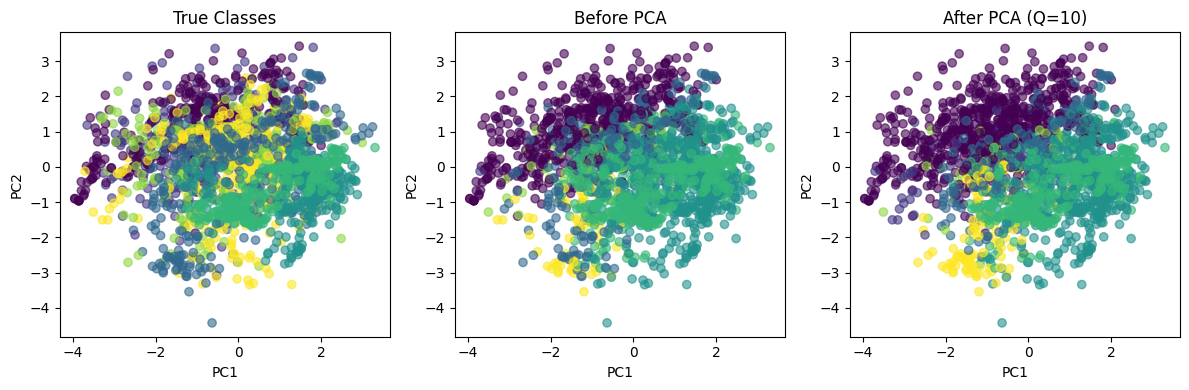

In [64]:
print(f"\nComparison:")
print(f"  Dimensionality: {X_processed.shape[1]} → {best_q}")
print(f"  Accuracy Before: {accuracy_before:.4f}")
print(f"  Accuracy After: {accuracy_after:.4f}")
print(f"  Difference: {accuracy_after - accuracy_before:.4f}")
if best_q >= 2:
    plt.figure(figsize=(12, 4))

    if best_q > 2:
        pca_vis = PCA_Scratch(n_comp=2)
        pca_vis.fit(X_processed)
        X_vis = pca_vis.transform(X_processed)
    else:
        X_vis = X_pca_best

    plt.subplot(131)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap='viridis', alpha=0.6)
    plt.title('True Classes')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    plt.subplot(132)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=winners_before, cmap='viridis', alpha=0.6)
    plt.title('Before PCA')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    plt.subplot(133)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=winners_after, cmap='viridis', alpha=0.6)
    plt.title(f'After PCA (Q={best_q})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    plt.tight_layout()
    plt.show()

# ===========================================================
# 11. DETAILED STATISTICAL ANALYSIS FOR REPORT
# ===========================================================

In [65]:
print("\n" + "="*60)
print("DETAILED ANALYSIS FOR REPORT")
print("="*60)

# 1. Dimensionality Reduction Analysis
print("\n1. DIMENSIONALITY REDUCTION:")
original_dim = X_processed.shape[1]
reduction_ratio = (original_dim - best_q) / original_dim * 100
print(f"   Original dimensions: {original_dim}")
print(f"   Best Q: {best_q}")
print(f"   Reduction: {reduction_ratio:.1f}%")

# 2. Information Preservation
print("\n2. INFORMATION PRESERVATION:")
print(f"   Reconstruction Error: {reconstruction_errors[best_q]:.4f}")
print(f"   Explained Variance: {explained_variances[best_q]:.4f}")

# 3. Performance Comparison
print("\n3. PERFORMANCE COMPARISON:")
print(f"   Hamming Network Accuracy (Original): {accuracy_before:.4f}")
print(f"   Hamming Network Accuracy (PCA): {accuracy_after:.4f}")
print(f"   Change: {accuracy_after - accuracy_before:.4f}")

# 4. Computational Efficiency
print("\n4. COMPUTATIONAL EFFICIENCY:")
print(f"   Original feature space size: {X_processed.shape[1]}")
print(f"   PCA feature space size: {best_q}")
print(f"   Memory reduction: {((X_processed.shape[1] - best_q) / X_processed.shape[1]) * 100:.1f}%")

# 5. Q Matrix Analysis
print("\n5. Q MATRIX SELECTION ANALYSIS:")
print("-" * 50)
print(f"{'Q':<5} {'Recon Error':<15} {'Explained Var':<15} {'Score':<10}")
print("-" * 50)
for q in Q_values:
    print(f"{q:<5} {reconstruction_errors[q]:<15.4f} {explained_variances[q]:<15.4f} {scores[q]:<10.4f}")


DETAILED ANALYSIS FOR REPORT

1. DIMENSIONALITY REDUCTION:
   Original dimensions: 31
   Best Q: 10
   Reduction: 67.7%

2. INFORMATION PRESERVATION:
   Reconstruction Error: 44.5527
   Explained Variance: 1.0000

3. PERFORMANCE COMPARISON:
   Hamming Network Accuracy (Original): 0.4969
   Hamming Network Accuracy (PCA): 0.5045
   Change: 0.0076

4. COMPUTATIONAL EFFICIENCY:
   Original feature space size: 31
   PCA feature space size: 10
   Memory reduction: 67.7%

5. Q MATRIX SELECTION ANALYSIS:
--------------------------------------------------
Q     Recon Error     Explained Var   Score     
--------------------------------------------------
2     118.8195        1.0000          0.3742    
3     107.8476        1.0000          0.4167    
5     86.2442         1.0000          0.5000    
10    44.5527         1.0000          0.6460    


In [66]:
print("\nCLASSIFICATION REPORT (BEFORE PCA):")
print(classification_report(y, winners_before))

print("\nCLASSIFICATION REPORT (AFTER PCA):")
print(classification_report(y, winners_after))


CLASSIFICATION REPORT (BEFORE PCA):
              precision    recall  f1-score   support

           0       0.46      0.97      0.63       272
           1       0.50      0.02      0.03       287
           2       0.60      0.35      0.44       351
           3       0.41      0.88      0.56       297
           4       0.60      1.00      0.75       324
           5       0.62      0.19      0.29       290
           6       0.27      0.07      0.11       290

    accuracy                           0.50      2111
   macro avg       0.50      0.50      0.40      2111
weighted avg       0.50      0.50      0.41      2111


CLASSIFICATION REPORT (AFTER PCA):
              precision    recall  f1-score   support

           0       0.39      0.99      0.56       272
           1       0.35      0.09      0.15       287
           2       0.74      0.28      0.41       351
           3       0.45      0.88      0.60       297
           4       0.76      1.00      0.86       324
     